In [24]:
import torch
from torchvision import datasets, transforms
from model import VAE
import const
from torch.utils.data import DataLoader, random_split, ConcatDataset, Subset
import matplotlib.pyplot as plt
import random
import numpy as np

# Prepare Rotated Dataset

The following function returns the combined datasets with specified rotation angles.

In [25]:
def get_rotated_mnist(raw_set, train, angles):
    total_set = [raw_set]
    for a in angles:
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.RandomRotation((a, a))
        ])
        total_set.append(datasets.MNIST(root=const.PATH_TO_MNIST, train=train, download=True, transform=transform))
    
    return ConcatDataset(total_set)

In [26]:
raw_testset = datasets.MNIST(root=const.PATH_TO_MNIST, train=False, download=True, transform=transforms.ToTensor())
raw_trainset = datasets.MNIST(root=const.PATH_TO_MNIST, train=True, download=True, transform=transforms.ToTensor())

# Interpolation

Direct interpolation between the source domain and the target domain.

In [27]:
def fail_plot(dataset, n, step, total_domains):
    size = len(dataset) // total_domains
    samples = [44671,50358,57548,59073,30711]
    
    f, ax = plt.subplots(n, step + 1)
    
    f.set_figheight(8)
    f.set_figwidth(10)
    
    for j in range(n):
        print(samples)
        # obtain samples in both source and target domains
        s = samples[j]
        img1 = dataset[s][0]
        img2 = dataset[s+size*(total_domains-1)][0]
        
        x1 = img1
        x2 = img2
        
        # perform linear interpolation
        for i in range(step + 1):
            x = (1-1/step * i) * x1[0] + 1/step * i * x2[0]
            
            ax[j, i].axis("off")
            ax[j, i].imshow(x, cmap="Greys_r")

In [28]:
@torch.no_grad()
def inter_plot_feature_vae(feature_vae, src_encoder, dataset, n, step, total_domains, device):
    size = len(dataset) // total_domains
    samples = [44671,50358,57548,59073,30711][:n]
    f, ax = plt.subplots(n, step + 1, figsize=(10, 8))

    feature_vae.eval()
    src_encoder.eval()

    for j, s in enumerate(samples):
        img1 = dataset[s][0].unsqueeze(0).to(device)                     # [1,1,28,28]
        img2 = dataset[s + size*(total_domains-1)][0].unsqueeze(0).to(device)

        z1 = src_encoder(img1).detach()                                  # feature space
        z2 = src_encoder(img2).detach()

        mu1, _ = feature_vae.encode_feature(z1)
        mu2, _ = feature_vae.encode_feature(z2)

        for i in range(step + 1):
            t = i / step
            z = (1 - t) * mu1 + t * mu2
            x = feature_vae.decode(z).squeeze().cpu()
            ax[j, i].imshow(x, cmap="Greys_r", vmin=0, vmax=1)
            ax[j, i].axis("off")


In [29]:
def inter_plot(model, dataset, n, step, total_domains):
    import torch
    device = next(model.parameters()).device
    model.eval()

    size = len(dataset) // total_domains
    # samples = random.sample(range(size), n)
    samples = [44671,50358,57548,59073,30711]

    f, ax = plt.subplots(n, step + 1)

    f.set_figheight(8)
    f.set_figwidth(10)

    with torch.no_grad():
        for j in range(n):
            # obtain samples in both source and target domains
            s = samples[j]
            img1 = dataset[s][0][0]
            img2 = dataset[s+size*(total_domains-1)][0][0]

            x1 = img1.unsqueeze(0).unsqueeze(0).to(device)
            x2 = img2.unsqueeze(0).unsqueeze(0).to(device)
            x1, x2 = model.encoder(x1), model.encoder(x2)

            # perform linear interpolation
            for i in range(step + 1):
                x = (1-1/step * i) * x1[0] + 1/step * i * x2[0]
                x = model.decoder(x).detach().reshape(28, 28).cpu()

                ax[j, i].axis("off")
                ax[j, i].imshow(x, cmap="Greys_r")



Interpolation between the source domain and the target domain through intermediate domains.

In [30]:
def inter_step_plot(model, dataset, n, step, total_domains):
    import torch
    device = next(model.parameters()).device
    model.eval()

    adapt_step = total_domains - 1
    size = len(dataset) // total_domains
    samples = random.sample(range(size), n)

    f, ax = plt.subplots(n, adapt_step * step + 1)

    f.set_figheight(15)
    f.set_figwidth(15)

    with torch.no_grad():
        for j in range(n):
            for k in range(adapt_step):
                s = samples[j]
                img1 = dataset[s+size*k][0]
                img2 = dataset[s+size*(k+1)][0]

                x1 = img1.unsqueeze(0).to(device)
                x2 = img2.unsqueeze(0).to(device)
                x1, x2 = model.encoder(x1), model.encoder(x2)

                for i in range(step):
                    x = (1-1/step * i) * x1[0] + 1/step * i * x2[0]
                    x = model.decoder(x).detach().reshape(28, 28).cpu()

                    ax[j, k*step+i].axis("off")
                    ax[j, k*step+i].imshow(x, cmap="Greys")

            x_last = model.decoder(x2[0]).detach().reshape(28, 28).cpu()
            ax[j, -1].axis("off")
            ax[j, -1].imshow(x_last, cmap="Greys")



Get interpolation with no intermediate domains.

In [31]:
import importlib
import const
import train_vae

importlib.reload(train_vae)

# const.DIM = 16
# vae = train_vae.train_goat_vae(
#     mode="mnist",
#     target=60,
#     save_path="./models/mnist/vae/vae_60_16.pt",
#     save=True,
# )


vae = VAE(x_dim=784, z_dim=16)
vae.load_state_dict(torch.load("./models/mnist/vae/vae_60_16.pt"))
angles = [60]
testset = get_rotated_mnist(raw_trainset, True, angles)

FileNotFoundError: [Errno 2] No such file or directory: './models/mnist/vae/vae_60_16.pt'

In [32]:
import torch
from torchvision import datasets, transforms
import const
from util import get_rotated_dataset
from qualitative_vae_compare import RMNISTVAE  # architecture used for --vae-input image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_path = "analysis_outputs/qualitative_mnist_target60/seed0_image_vae/image_vae_target60_z128_ssl0p1_seed0.pt"
ckpt = torch.load(ckpt_path, map_location=device)

z_dim = int(ckpt["latent_dim"])  # should be 128
vae = RMNISTVAE(x_dim=28*28, z_dim=z_dim).to(device)
vae.load_state_dict(ckpt["state_dict"], strict=True)
vae = vae.to(device)
vae.eval()

# build dataset for plotting
raw_trainset = datasets.MNIST(root=const.PATH_TO_MNIST, train=True, download=True, transform=transforms.ToTensor())
angles = [60]
testset = get_rotated_dataset(raw_trainset, True, angles)  # source + target


In [33]:
import torch
from qualitative_vae_compare import FeatureToImageVAE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_path = "/home/yuen_chen/GOAT/analysis_outputs/qualitative_mnist_target60_ssl0p1/seed0_feature_traj_fallback_gen6_img10/feature_vae_target60_z128_ssl0p1_seed0.pt"
ckpt = torch.load(ckpt_path, map_location=device)

feat_dim = int(ckpt["feature_dim"])
z_dim = int(ckpt["latent_dim"])

vae = FeatureToImageVAE(feature_dim=feat_dim, latent_dim=z_dim, image_dim=28*28).to(device)
vae.load_state_dict(ckpt["state_dict"], strict=True)
vae.eval()


FeatureToImageVAE(
  (feature_enc): Sequential(
    (0): Linear(in_features=2048, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=1024, bias=True)
    (3): ReLU()
  )
  (mu): Linear(in_features=1024, out_features=128, bias=True)
  (logvar): Linear(in_features=1024, out_features=128, bias=True)
  (image_dec): RMNISTDecoder(
    (decode): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(1, 1))
      (1): ReLU()
      (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(1, 1))
      (4): ReLU()
      (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(1, 1))
      (7): ReLU()
      (8): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (9): ConvTranspose2d(16, 8, kernel_size=(3, 3), stride=(1, 1

In [34]:
import torch
from torchvision import datasets, transforms
from qualitative_vae_compare import _ensure_default_args
from experiment_refrac import ModelConfig, build_reference_model
from model import ENCODER
import argparse

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# datasets (same target angle as your feature VAE)
target_angle = 60
src_trainset = datasets.MNIST(root=const.PATH_TO_MNIST, train=True, download=True, transform=transforms.ToTensor())
tgt_trainset = get_single_rotate(False, target_angle)  # same utility as script

# minimal args object
args = argparse.Namespace(
    dataset="mnist",
    seed=0,
    batch_size=256,
    num_workers=2,
    small_dim=2048,
    ssl_weight=0.1,
    lr=1e-4,
    pseudo_confidence_q=0.9,
    use_labels=False,
    diet=False,
    mnist_mode="normal",
    em_cov_types=["diag"],
    em_seeds=[0,1,2],
    em_pca_dims=[None],
    em_K_list=[10],
)
args = _ensure_default_args(args)

model_cfg = ModelConfig(
    encoder_builder=ENCODER,
    mode="mnist",
    n_class=10,
    epochs=10,
    model_path="analysis_outputs/qualitative_mnist_target60_ssl0p1/seed0_feature_traj_fallback_gen6_img10/models/src0_tgt60_ssl0.1_dim2048.pth",
    compress=True,
    in_dim=25088,
    out_dim=args.small_dim,
)

ref_model, ref_encoder = build_reference_model(args, model_cfg, src_trainset, tgt_trainset)
src_encoder = ref_encoder.to(device).eval()


NameError: name 'get_single_rotate' is not defined

[44671, 50358, 57548, 59073, 30711]
[44671, 50358, 57548, 59073, 30711]
[44671, 50358, 57548, 59073, 30711]
[44671, 50358, 57548, 59073, 30711]
[44671, 50358, 57548, 59073, 30711]


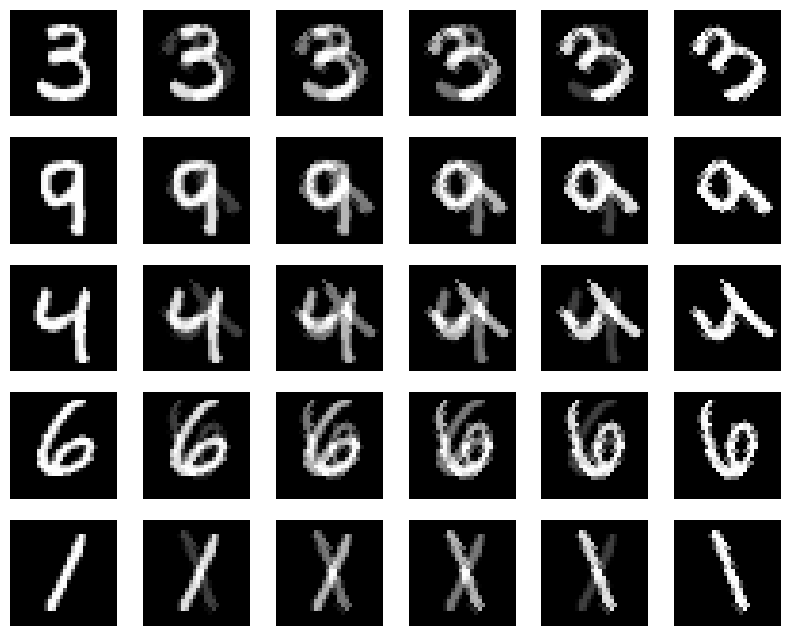

In [30]:
fail_plot(testset, 5, 5, len(angles)+1)

In [ ]:
vae = VAE(x_dim=784, h_dim1= 512, h_dim2=256, z_dim=const.DIM)
vae.load_state_dict(torch.load("./models/vae/bn_vae_60_16_new.pt", map_location=torch.device('cpu')))
angles = [60]
testset = get_rotated_mnist(raw_trainset, True, angles)

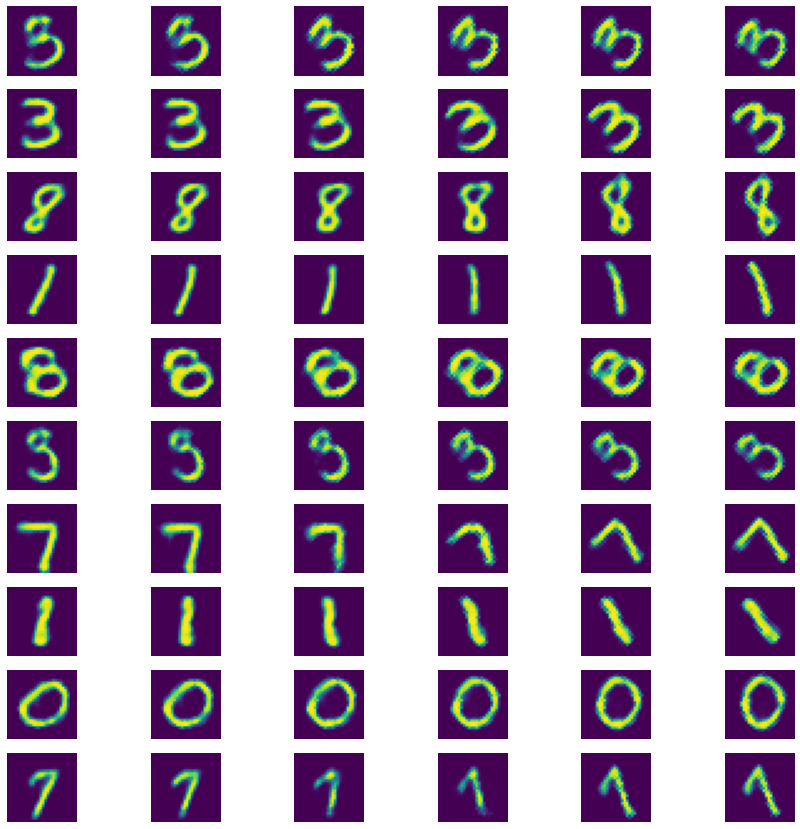

In [10]:
inter_plot(vae, testset, 10, 5, len(angles)+1)

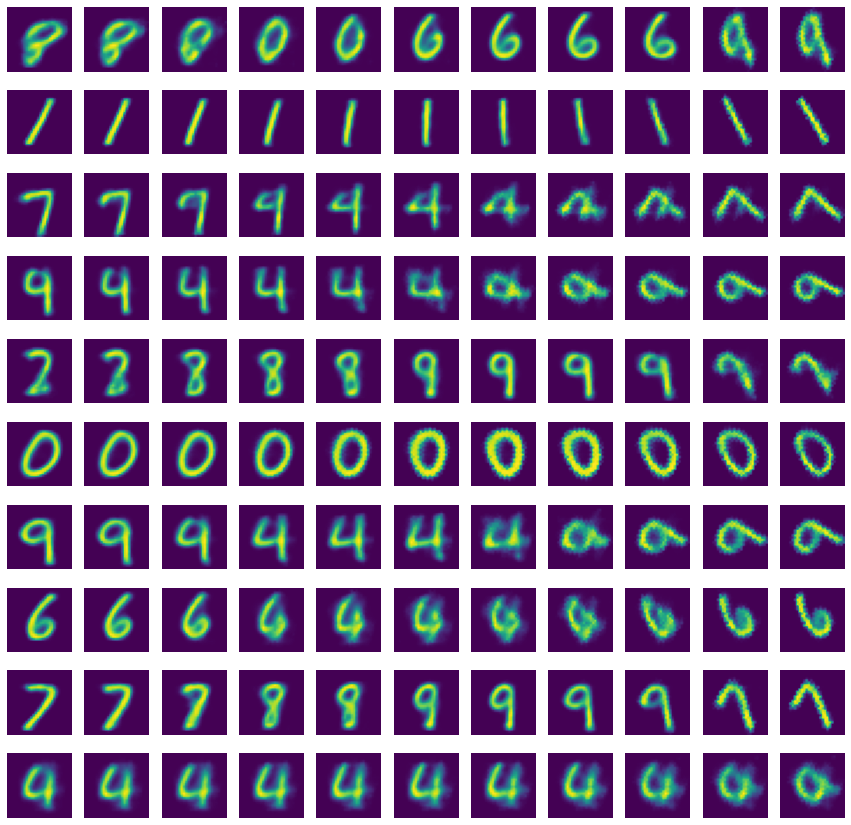

In [121]:
vae = VAE(x_dim=784, h_dim1= 512, h_dim2=256, z_dim=5)
vae.load_state_dict(torch.load("./models/vanilla_vae_1.pt", map_location=torch.device('cpu')))
angles = [60]
testset = get_rotated_mnist(raw_trainset, True, angles)
inter_plot(vae, testset, 10, 10, len(angles)+1)

Get plot for interpolation with 1 existing intermedate domain.The plot shows the direct interpolation between 0 and 60 degree.

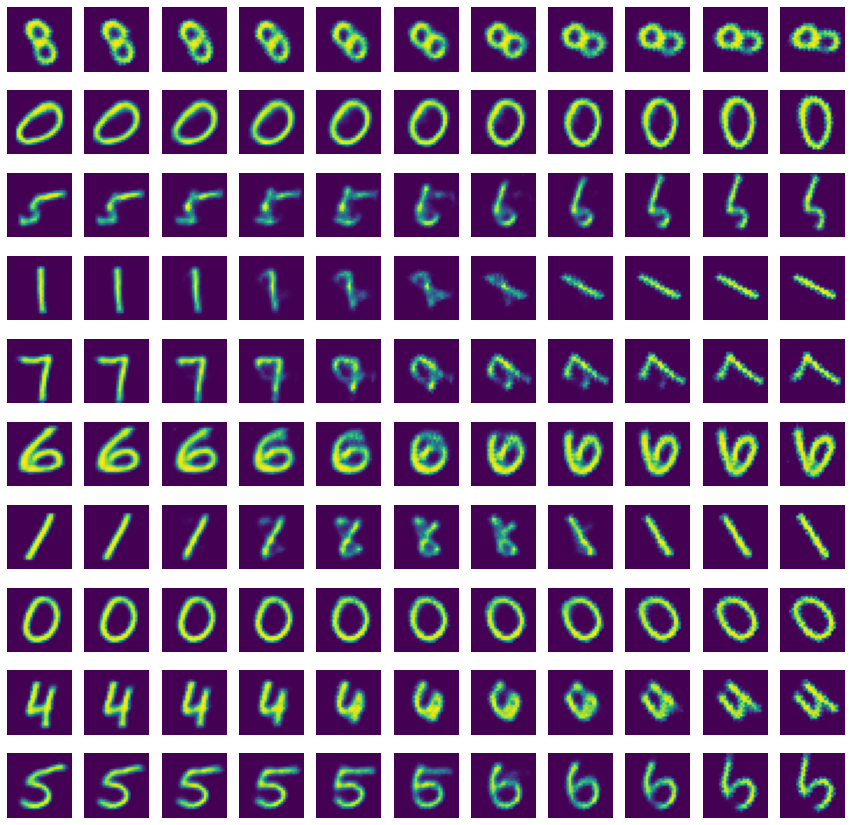

In [15]:
vae2 = VAE(x_dim=784, h_dim1= 512, h_dim2=256, z_dim=16)
vae2.load_state_dict(torch.load("./models/vae_2_16.pt", map_location=torch.device('cpu')))
angles = [30, 60]
testset2 = get_rotated_mnist(raw_testset, False, angles)
inter_plot(vae2, testset2, 10, 10, len(angles)+1)

The plot shows the interpolation between 0 and 30 degree first, then 30 to 60 degree.

C:\Users\rapha\anaconda3\envs\nn\lib\site-packages\torch\nn\functional.py:1806: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


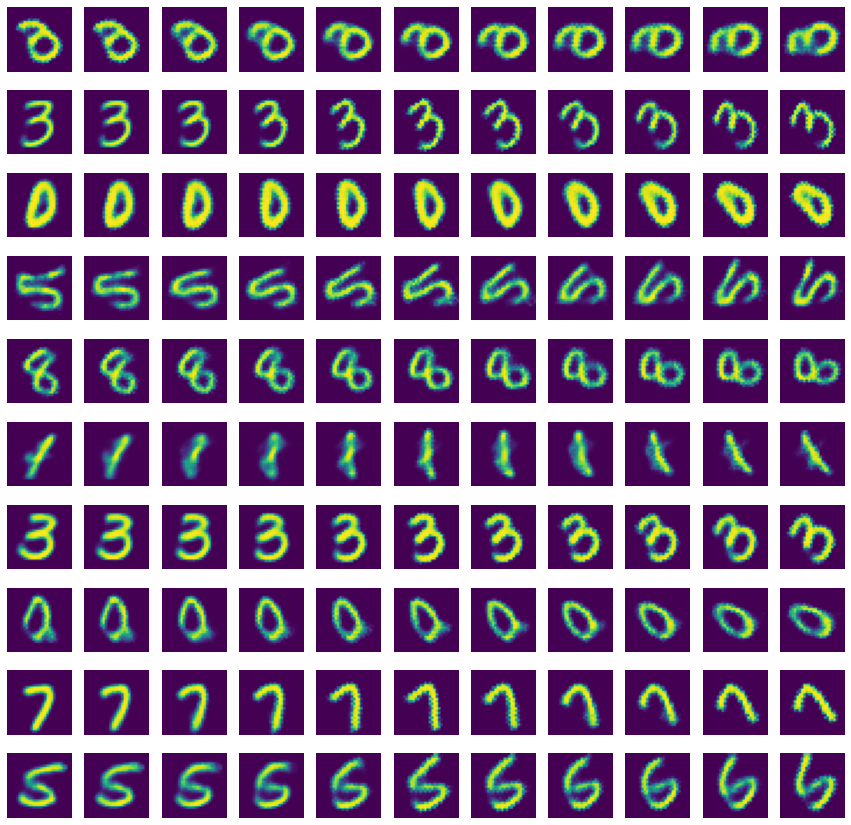

In [43]:
inter_step_plot(vae2, testset2, 10, 5, len(angles)+1)

Get plot for interpolation with 3 existing intermedate domains. The plot shows the direct interpolation between 0 and 60 degree.

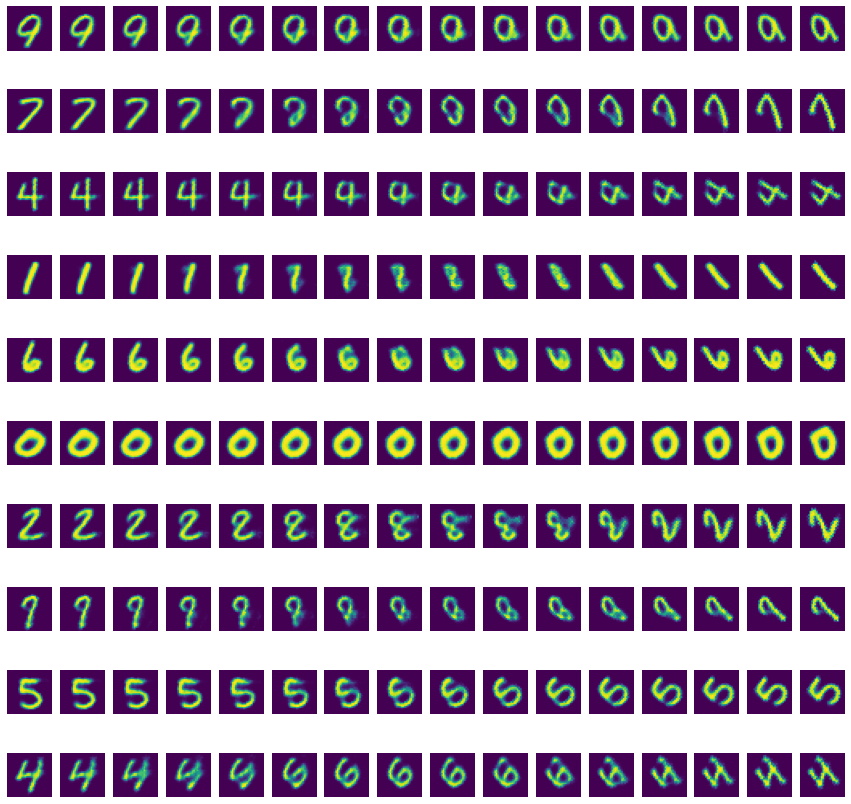

In [ ]:
vae4 = VAE(x_dim=784, h_dim1= 512, h_dim2=256, z_dim=16)
vae4.load_state_dict(torch.load("./models/vae_4_16.pt", map_location=torch.device('cpu')))
angles = [15, 30, 60, 60]
testset4 = get_rotated_mnist(raw_testset, False, angles)
inter_plot(vae4, testset4, 10, 15, len(angles)+1)

The plot shows the interpolation between 0 and 15 degree first, then 15 to 30 degree, 30 to 60 degree and 60 to 60 degree.

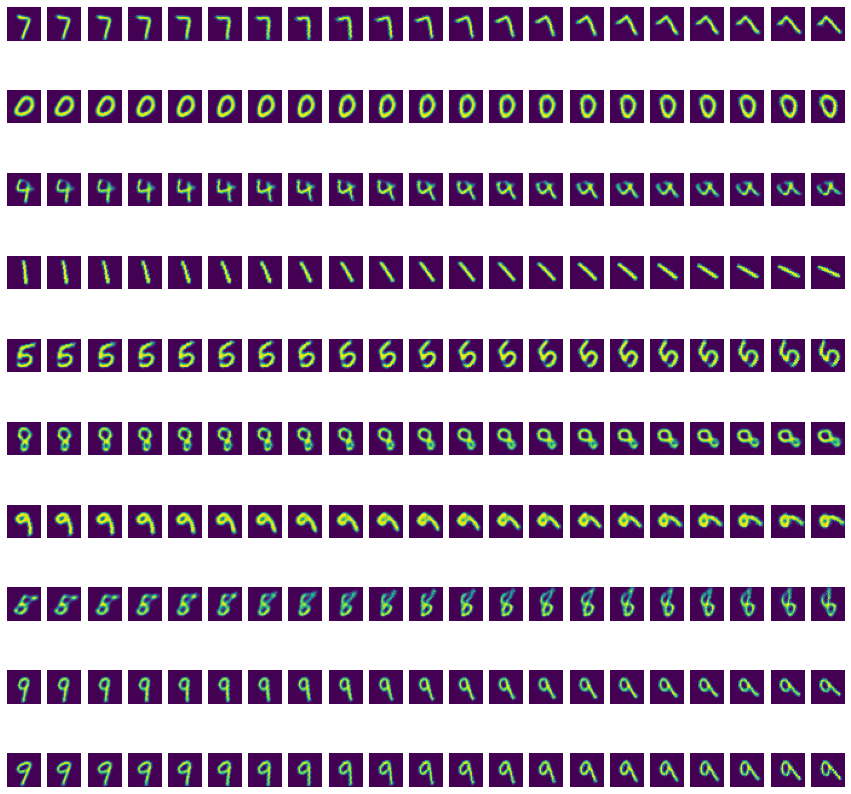

In [82]:
inter_step_plot(vae4, testset4, 10, 5, len(angles)+1)

# Optimal Transport

In [21]:
import ot

The following uses optimal transport with sinkhorn solver (entropy regularizer).

In [125]:
def get_sinkhorn(dataset, model, total_domains, reg):
    size = len(dataset) // total_domains
    
    dataloader = DataLoader(dataset, batch_size=len(dataset), shuffle=False, num_workers=2)
    with torch.no_grad():
        for data, _ in dataloader:
            encoded = model.encoder(data)[0]
    
    x = []
    for i in range(total_domains):
        x.append(encoded[i*size: (i+1)*size])
    
    ot_models = []
    for i in range(total_domains-1):
        ot_sinkhorn = ot.da.SinkhornTransport(reg_e=reg)
        ot_sinkhorn.fit(Xs=x[i].detach().numpy(), Xt=x[i+1].detach().numpy())
#         ot_sinkhorn = ot.da.SinkhornL1l2Transport(reg_e=0.1, reg_cl=2)
#         ot_sinkhorn.fit(Xs=x[i].detach().numpy(), Xt=x[i+1].detach().numpy(), ys=raw_testset.targets.detach().numpy())
        ot_models.append(ot_sinkhorn)
        
    return ot_models

In [102]:
def sinkhorn_plot(dataset, model, ot_models, total_domains, n, reg=1):
    size = len(dataset) // total_domains
    samples = random.sample(range(size), n)
    print(samples)
    
    dataloader = DataLoader(dataset, batch_size=len(dataset), shuffle=False, num_workers=2)
    with torch.no_grad():
        for data, _ in dataloader:
            encoded = model.encoder(data)[0]
    
    x = []
    for i in range(total_domains):
        x.append(encoded[i*size: (i+1)*size])
    
    f, ax = plt.subplots(n, 2 * total_domains - 1)
    f.set_figheight(15)
    f.set_figwidth(15)
        
    ot_x = []
    for i in range(total_domains):
        cur_x = []
        for j in range(n):
            if i == 0:
                trans_x = model.encoder(dataset[samples[j]][0].unsqueeze(0))[0]
            else:
                og_x = ot_x[i-1][j]
                trans_x = ot_models[i-1].transform(Xs=og_x.detach().numpy().reshape(1, -1))
                trans_x = torch.Tensor(trans_x)
            show_x = model.decoder(torch.Tensor(trans_x)).detach().reshape(28, 28)
            ax[j, i].axis("off")
            ax[j, i].imshow(show_x)
            cur_x.append(trans_x)
        ot_x.append(cur_x)

    for i in range(n):
        for j in range(1, total_domains):
            trans_x = model.decoder(x[j][samples[i]]).detach().reshape(28, 28)
            ax[i, total_domains+j-1].axis("off")
            ax[i, total_domains+j-1].imshow(trans_x)
    
    cols = ["original"] + ["ot"] * (total_domains-1) + ["original"] * (total_domains-1)
    for a, col in zip(ax[0], cols):
        a.set_title(col)
        

In [126]:
ot_models2 = get_sinkhorn(testset2, vae2, 3, 1)
# ot_models4 = get_sinkhorn(testset4, vae4, 5, 1)

In [116]:
ot_models2 = get_sinkhorn(testset2, vae2, 3, 1)

[864, 9004, 4804, 5462, 6018, 9858, 1706, 5341, 8500, 4828]


Exception ignored in: <function _ConnectionBase.__del__ at 0x0000025B98917430>
Traceback (most recent call last):
  File "C:\Users\rapha\anaconda3\envs\nn\lib\multiprocessing\connection.py", line 137, in __del__
    self._close()
  File "C:\Users\rapha\anaconda3\envs\nn\lib\multiprocessing\connection.py", line 282, in _close
    _CloseHandle(self._handle)
OSError: [WinError 6] 句柄无效。


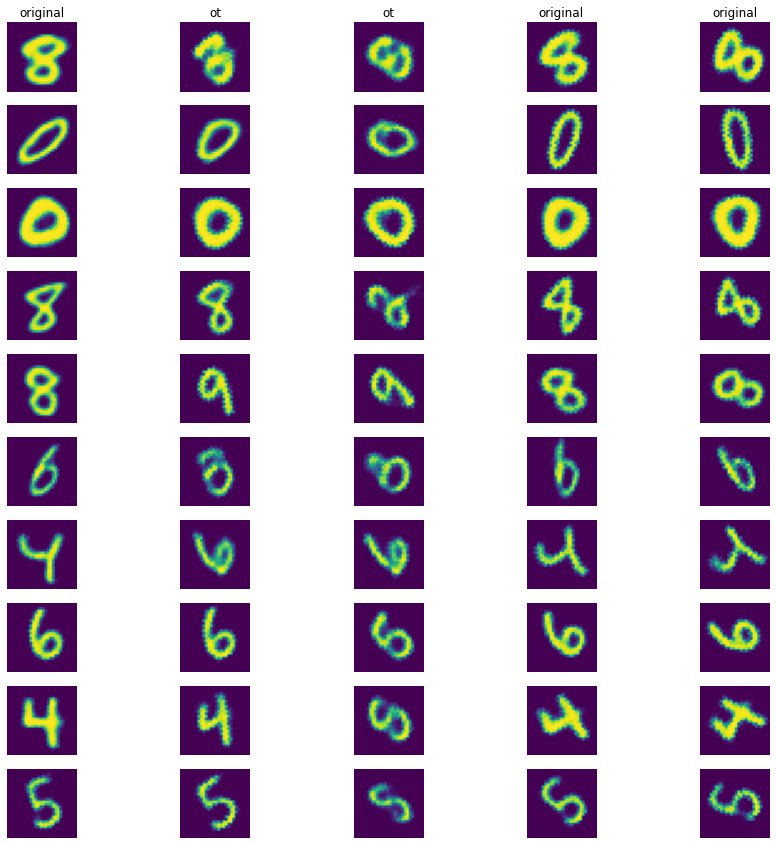

In [127]:
sinkhorn_plot(testset2, vae2, ot_models2, 3, 10, 1)

[9499, 552, 3139, 4872, 9618]


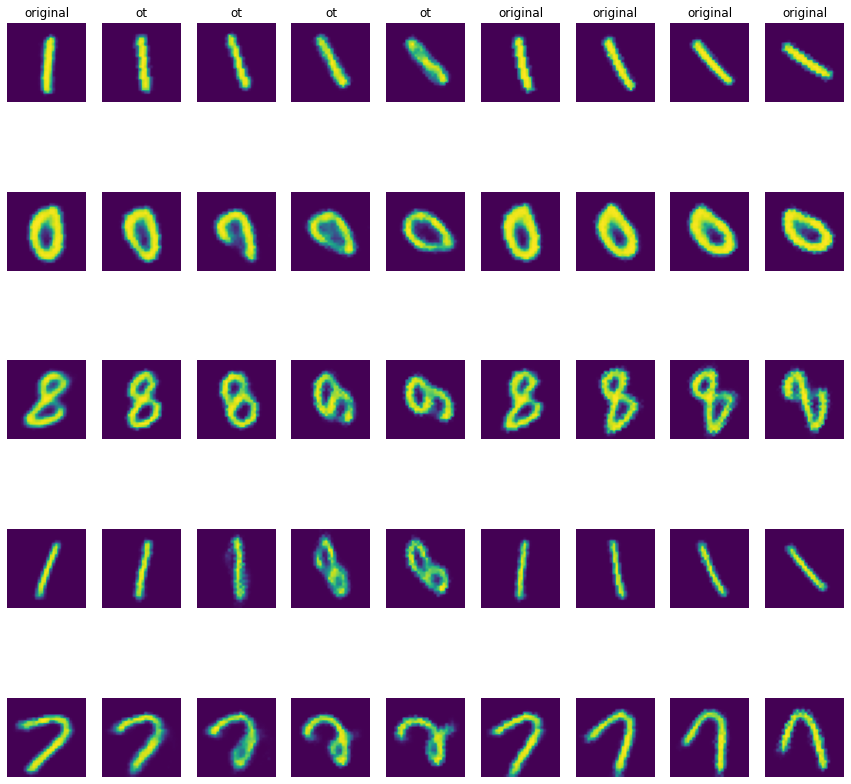

In [120]:
sinkhorn_plot(testset4, vae4, ot_models4, 5, 5, 1)

The sinkhorn algorithm does not seem easy to converge for the direct adaption case. Leave for later.

In [16]:
# sinkhorn_plot(testset, vae, 2, 5, 1)

## Interpolation result for OT

In [74]:
def sinkhorn_inter_plot(dataset, model, ot_models, total_domains, n=10, step=5, reg=1):
    size = len(dataset) // total_domains
    samples = random.sample(range(size), n)
    
    f, ax = plt.subplots(n, (total_domains-1) * step+1)
    f.set_figheight(15)
    f.set_figwidth(15)
    
    ot_x = []
    
    for i in range(total_domains):
        cur_x = []
        for j in range(n):
            if i == 0:
                trans_x = model.encoder(dataset[samples[j]][0].unsqueeze(0))[0]
            else:
                og_x = ot_x[i-1][j]
                trans_x = ot_models[i-1].transform(Xs=og_x.detach().numpy().reshape(1, -1))
                trans_x = torch.Tensor(trans_x)
            cur_x.append(trans_x)
        ot_x.append(cur_x)
    
    for j in range(n):
        for k in range(total_domains-1):
            x1, x2 = ot_x[k][j], ot_x[k+1][j]

            for i in range(step):
                x = (1-1/step * i) * x1[0] + 1/step * i * x2[0]
                x = x.unsqueeze(0).float()
                x = model.decoder(x).detach().reshape(28, 28)

                ax[j, k*step+i].axis("off")
                ax[j, k*step+i].imshow(x)
        
        x_last = model.decoder(ot_x[k][-1].unsqueeze(0).float()).detach().reshape(28, 28)
        ax[j, -1].axis("off")
        ax[j, -1].imshow(x_last)
    

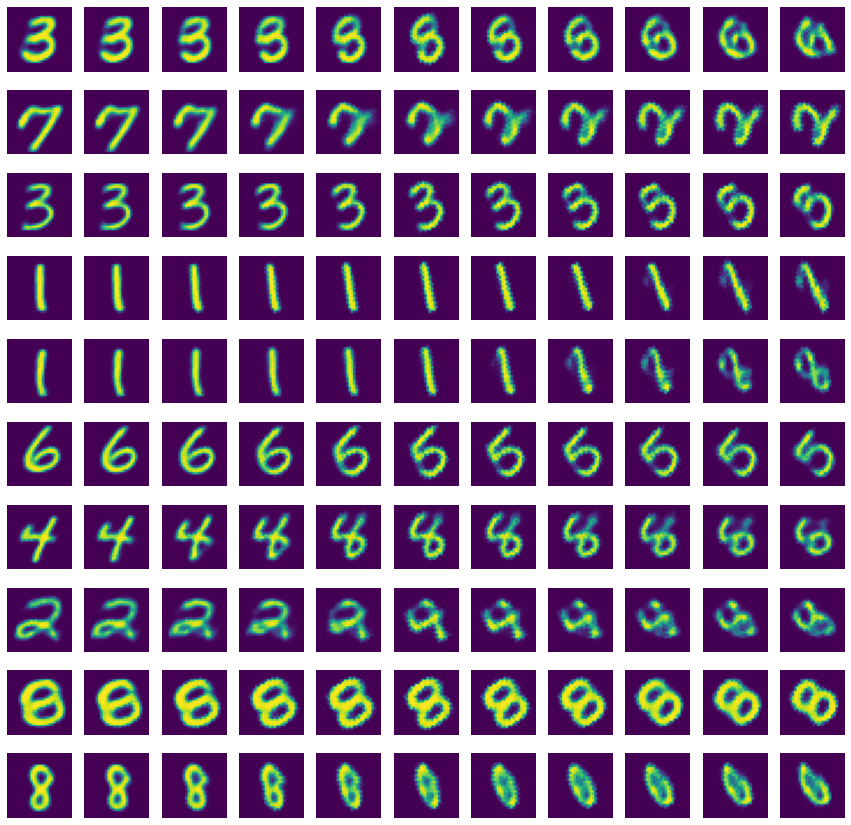

In [88]:
sinkhorn_inter_plot(testset2, vae2, ot_models2, 3)

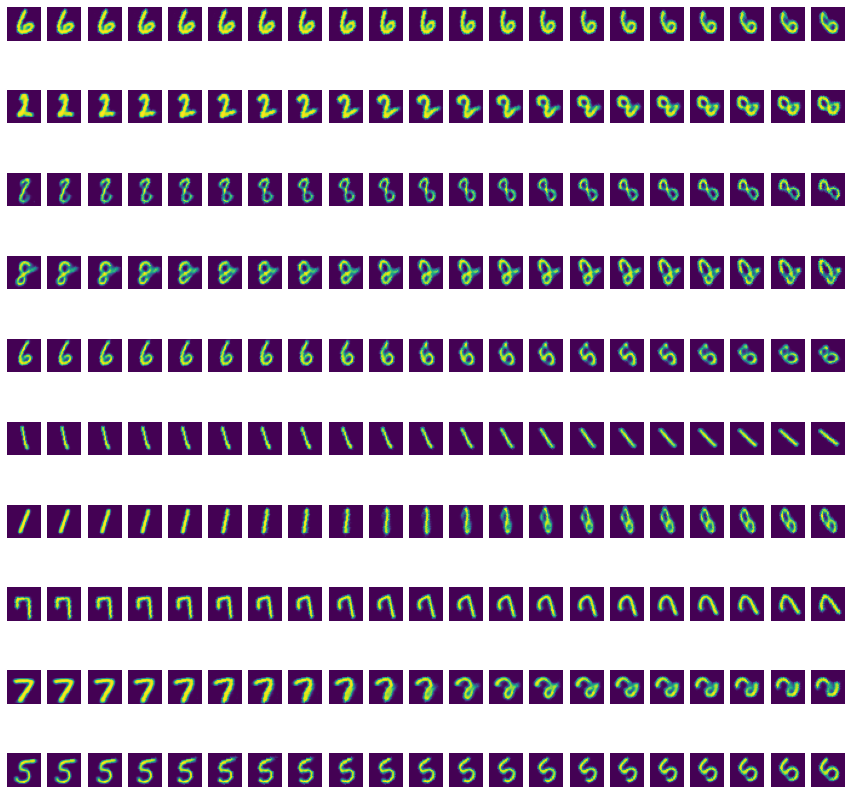

In [84]:
sinkhorn_inter_plot(testset4, vae4, ot_models4, 5)

## Compare All Interpolation Methods

Use one row per method, shared sample indices across all methods/steps, and optional class filtering.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch


def plot_all_methods_trajectories(
    methods_to_domains,
    decode_fn,
    class_id=None,
    n_samples=1,
    seed=0,
    out_png="trajectory_all_methods.png",
):
    """
    methods_to_domains: dict[str, list[domain_ds]]
      each domain_ds must expose `.data` and optionally `.targets` / `.targets_em`.
      each list should be ordered source -> ... -> target.

    decode_fn: callable(feat_tensor)->images of shape [N,1,28,28], in [0,1]
    """
    method_names = list(methods_to_domains.keys())
    if len(method_names) == 0:
        raise ValueError("methods_to_domains is empty")

    n_cols = min(len(v) for v in methods_to_domains.values())
    method_names = [m for m in method_names if len(methods_to_domains[m]) >= n_cols]
    if n_cols <= 0:
        raise ValueError("No trajectory domains found")

    def _labels(ds):
        y = getattr(ds, "targets", None)
        if y is None:
            y = getattr(ds, "targets_em", None)
        return None if y is None else torch.as_tensor(y).long().view(-1)

    min_len = min(len(methods_to_domains[m][c].data) for m in method_names for c in range(n_cols))
    if min_len <= 0:
        raise ValueError("No samples available in trajectory domains")

    mask = np.ones(min_len, dtype=bool)
    if class_id is not None:
        for m in method_names:
            for c in range(n_cols):
                ds = methods_to_domains[m][c]
                y = _labels(ds)
                if y is None:
                    raise ValueError(f"class_id filtering requested but labels missing for {m} step {c}")
                yy = y.cpu().numpy()[:min_len]
                mask &= (yy == int(class_id))

    valid = np.where(mask)[0]
    if len(valid) == 0:
        raise RuntimeError("No shared indices found across methods/steps with current filter")

    rng = np.random.default_rng(seed)
    n_pick = min(int(n_samples), len(valid))
    idx = np.sort(rng.choice(valid, size=n_pick, replace=False))

    fig, axes = plt.subplots(len(method_names), n_cols, figsize=(2.25 * n_cols, 1.95 * len(method_names)), squeeze=False)

    for r, m in enumerate(method_names):
        for c in range(n_cols):
            ds = methods_to_domains[m][c]
            feat = ds.data
            feat = feat[idx] if torch.is_tensor(feat) else torch.as_tensor(feat[idx])
            imgs = decode_fn(feat)
            if not torch.is_tensor(imgs):
                imgs = torch.as_tensor(imgs)
            imgs = imgs.detach().cpu()
            # make strip: [N,1,28,28] -> [28, N*28]
            strip = np.concatenate([imgs[i, 0].numpy() for i in range(imgs.shape[0])], axis=1)

            ax = axes[r, c]
            ax.imshow(strip, cmap="gray", vmin=0.0, vmax=1.0, aspect="auto")
            ax.set_xticks([])
            ax.set_yticks([])

            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(0.8)
                spine.set_color("#222222")

            for k in range(1, len(idx)):
                ax.axvline(28 * k - 0.5, color="#f3f3f3", lw=0.8, alpha=0.9)

            if r == 0:
                domain_tag = "Real" if (c == 0 or c == n_cols - 1) else "Synthetic"
                ax.set_title(f"{domain_tag}\nStep {c}", fontsize=9, fontweight="bold")
            if c == 0:
                ax.set_ylabel(m, fontsize=10, fontweight="bold", rotation=0, labelpad=30, va="center")

    cls_txt = f", class={class_id}" if class_id is not None else ""
    fig.suptitle(f"All-method trajectories (shared idx={idx.tolist()}{cls_txt})", fontsize=13, fontweight="bold")
    fig.tight_layout(rect=(0.01, 0.02, 1.0, 0.95))
    fig.savefig(out_png, dpi=350, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_png}")


# Example usage:
# plot_all_methods_trajectories(
#     methods_to_domains={
#         "GOAT": goat_chain,
#         "GOAT-CW": goatcw_chain,
#         "OURS-FR": ours_fr_chain,
#         "OURS-Nat": ours_nat_chain,
#     },
#     decode_fn=lambda f: decode_features(vae, f),
#     class_id=6,        # set None for no class filter
#     n_samples=1,
#     seed=0,
#     out_png="trajectory_all_methods_class6.png",
# )


## Clean GOAT Workflow (Patched)
Use only one path at a time:
- **Image VAE** checkpoint (`image_vae_...pt`) with `inter_plot`
- **Feature VAE** checkpoint (`feature_vae_...pt`) with `inter_plot_feature_vae` + `src_encoder`

Avoid mixing with legacy VAE cells above.

In [42]:
import torch
import argparse
import const
from torchvision import datasets, transforms
from util import get_rotated_dataset, get_single_rotate
from qualitative_vae_compare import RMNISTVAE, FeatureToImageVAE, _ensure_default_args
from experiment_refrac import ModelConfig, build_reference_model
from model import ENCODER

# -----------------------
# User settings
# -----------------------
TARGET_ANGLE = 60
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_CKPT = f"analysis_outputs/qualitative_mnist_target{TARGET_ANGLE}/seed0_image_vae/image_vae_target{TARGET_ANGLE}_z128_ssl0p1_seed0.pt"
FEATURE_CKPT = f"analysis_outputs/qualitative_mnist_target{TARGET_ANGLE}_ssl0p1/seed0_feature_traj_fallback_gen6_img10/feature_vae_target{TARGET_ANGLE}_z128_ssl0p1_seed0.pt"

# Dataset for plotting (source + target)
raw_trainset = datasets.MNIST(root=const.PATH_TO_MNIST, train=True, download=True, transform=transforms.ToTensor())
angles = [TARGET_ANGLE]
testset = get_rotated_dataset(raw_trainset, True, angles)

vae_img = None
vae_feat = None
src_encoder = None


def load_image_vae(ckpt_path=IMAGE_CKPT):
    global vae_img
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    z_dim = int(ckpt["latent_dim"])
    vae_img = RMNISTVAE(x_dim=28 * 28, z_dim=z_dim).to(DEVICE)
    vae_img.load_state_dict(ckpt["state_dict"], strict=True)
    vae_img.eval()
    print(f"[OK] Loaded image VAE: {ckpt_path}")
    return vae_img


def load_feature_vae_and_encoder(feature_ckpt=FEATURE_CKPT):
    global vae_feat, src_encoder

    ckpt = torch.load(feature_ckpt, map_location=DEVICE)
    feat_dim = int(ckpt["feature_dim"])
    z_dim = int(ckpt["latent_dim"])
    vae_feat = FeatureToImageVAE(feature_dim=feat_dim, latent_dim=z_dim, image_dim=28 * 28).to(DEVICE)
    vae_feat.load_state_dict(ckpt["state_dict"], strict=True)
    vae_feat.eval()

    args = argparse.Namespace(
        dataset="mnist", seed=0, batch_size=256, num_workers=2,
        small_dim=2048, ssl_weight=0.1, lr=1e-4,
        pseudo_confidence_q=0.9, use_labels=False, diet=False, mnist_mode="normal",
        em_cov_types=["diag"], em_seeds=[0, 1, 2], em_pca_dims=[None], em_K_list=[10],
    )
    args = _ensure_default_args(args)

    src_trainset = datasets.MNIST(root=const.PATH_TO_MNIST, train=True, download=True, transform=transforms.ToTensor())
    tgt_trainset = get_single_rotate(False, TARGET_ANGLE)
    model_cfg = ModelConfig(
        encoder_builder=ENCODER,
        mode="mnist",
        n_class=10,
        epochs=10,
        model_path=f"analysis_outputs/qualitative_mnist_target{TARGET_ANGLE}_ssl0p1/seed0_feature_traj_fallback_gen6_img10/models/src0_tgt{TARGET_ANGLE}_ssl0.1_dim2048.pth",
        compress=True,
        in_dim=25088,
        out_dim=2048,
    )
    _, ref_encoder = build_reference_model(args, model_cfg, src_trainset, tgt_trainset)
    src_encoder = ref_encoder.to(DEVICE).eval()

    print(f"[OK] Loaded feature VAE: {feature_ckpt}")
    print("[OK] Loaded source encoder for feature plotting")
    return vae_feat, src_encoder

print("[OK] Ready. Call load_image_vae() or load_feature_vae_and_encoder() before plotting.")


[OK] Ready. Call load_image_vae() or load_feature_vae_and_encoder() before plotting.


In [43]:
import argparse
import torch
import const
from torchvision import datasets, transforms
from util import get_single_rotate
from qualitative_vae_compare import _ensure_default_args
from experiment_refrac import ModelConfig, build_reference_model
from model import ENCODER

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TARGET_ANGLE = 60

args = argparse.Namespace(
    dataset="mnist",
    seed=0,
    batch_size=256,
    num_workers=2,
    small_dim=2048,
    ssl_weight=0.1,
    lr=1e-4,
    pseudo_confidence_q=0.9,
    use_labels=False,
    diet=False,
    mnist_mode="normal",
    em_cov_types=["diag"],
    em_seeds=[0, 1, 2],
    em_pca_dims=[None],
    em_K_list=[10],
)
args = _ensure_default_args(args)

src_trainset = datasets.MNIST(root=const.PATH_TO_MNIST, train=True, download=True, transform=transforms.ToTensor())
tgt_trainset = get_single_rotate(False, TARGET_ANGLE)

model_cfg = ModelConfig(
    encoder_builder=ENCODER,
    mode="mnist",
    n_class=10,
    epochs=10,
    model_path=f"analysis_outputs/qualitative_mnist_target{TARGET_ANGLE}_ssl0p1/seed0_feature_traj_fallback_gen6_img10/models/src0_tgt{TARGET_ANGLE}_ssl0.1_dim2048.pth",
    compress=True,
    in_dim=25088,
    out_dim=2048,
)

_, ref_encoder = build_reference_model(args, model_cfg, src_trainset, tgt_trainset)
src_encoder = ref_encoder.to(DEVICE).eval()
print("src_encoder loaded:", type(src_encoder))


[get_source_model] detected encoder flat_dim=25088
[Cache] Loading trained model from analysis_outputs/qualitative_mnist_target60_ssl0p1/seed0_feature_traj_fallback_gen6_img10/models/src0_tgt60_ssl0.1_dim2048.pth
src_encoder loaded: <class 'torch.nn.modules.container.Sequential'>


[get_source_model] detected encoder flat_dim=25088
[Cache] Loading trained model from analysis_outputs/qualitative_mnist_target60_ssl0p1/seed0_feature_traj_fallback_gen6_img10/models/src0_tgt60_ssl0.1_dim2048.pth
[OK] Loaded feature VAE: analysis_outputs/qualitative_mnist_target60_ssl0p1/seed0_feature_traj_fallback_gen6_img10/feature_vae_target60_z128_ssl0p1_seed0.pt
[OK] Loaded source encoder for feature plotting


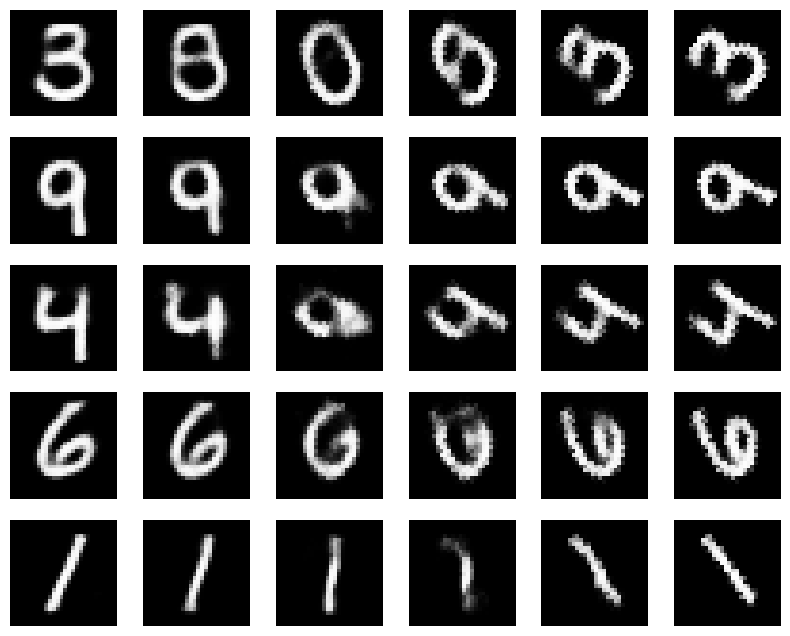

: 

In [ ]:
# Plot call (choose by MODE)
MODE = "feature"  # "image" or "feature"

if MODE == "image":
    if vae_img is None:
        load_image_vae()
    inter_plot(vae_img, testset, 5, 5, len(angles) + 1)

elif MODE == "feature":
    if vae_feat is None or src_encoder is None:
        load_feature_vae_and_encoder()
    inter_plot_feature_vae(
        vae_feat,
        src_encoder,
        testset,
        n=5,
        step=5,
        total_domains=len(angles) + 1,
        device=DEVICE,
    )
else:
    raise ValueError("MODE must be 'image' or 'feature'")
